In [1]:
import os
import cv2
import numpy as np
import pandas as  pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchsummary import summary
from model.resnet import Resnet34Triplet

In [2]:
flag_gpu_available = torch.cuda.is_available()
if flag_gpu_available:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(device)

cuda


In [3]:
checkpoint = torch.load('model/model_resnet34_triplet.pt', map_location=device)
model = Resnet34Triplet(embedding_dimension=checkpoint['embedding_dimension'])
model.load_state_dict(checkpoint['model_state_dict'])
best_distance_threshold = checkpoint['best_distance_threshold']

model.to(device)
model.eval()

Resnet34Triplet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [4]:
summary(model, input_size = (3, 112, 112), batch_size = -1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 56, 56]           9,408
       BatchNorm2d-2           [-1, 64, 56, 56]             128
              ReLU-3           [-1, 64, 56, 56]               0
         MaxPool2d-4           [-1, 64, 28, 28]               0
            Conv2d-5           [-1, 64, 28, 28]          36,864
       BatchNorm2d-6           [-1, 64, 28, 28]             128
              ReLU-7           [-1, 64, 28, 28]               0
            Conv2d-8           [-1, 64, 28, 28]          36,864
       BatchNorm2d-9           [-1, 64, 28, 28]             128
             ReLU-10           [-1, 64, 28, 28]               0
       BasicBlock-11           [-1, 64, 28, 28]               0
           Conv2d-12           [-1, 64, 28, 28]          36,864
      BatchNorm2d-13           [-1, 64, 28, 28]             128
             ReLU-14           [-1, 64,

In [5]:
similarity = nn.CosineSimilarity(dim=0, eps=1e-6)

In [6]:
def create_embedding(imgs_path, save_name, face_model):
    transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(size=(140,140)),  # Pre-trained model uses 140x140 input images
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.6071, 0.4609, 0.3944],  # Normalization settings for the model, the calculated mean and std values
                    std=[0.2457, 0.2175, 0.2129]     # for the RGB channels of the tightly-cropped glint360k face dataset
                )
    ])
    
    img_names = [os.path.join(imgs_path, x) for x in os.listdir(imgs_path)]
    face_names = []
    embeddings_list = []
    
    for index, img_name in enumerate(img_names):
        if index % 2 == 0:
            print("Computing embedding... {}/{}".format(index, len(img_names)))
        
        #print(img_name)
        face_names.append(img_name)
        #print(face_names)
        
        img = cv2.imread(img_name)  # Or from a cv2 video capture stream

        # Note that you need to use a face detection model here to crop the face from the image and then
        #  create a new face image object that will be inputted to the facial recognition model later.

        # Convert the image from BGR color (which OpenCV uses) to RGB color
        img = img[:, :, ::-1]
    
        img = transform(img)
        img = img.unsqueeze(0)
        img = img.to(device)

        embedding = face_model(img)
        embedding = torch.flatten(embedding)
        embedding = embedding.cpu().detach().numpy()
        
#         embedding = embedding.cpu().detach().numpy()
#         embedding = np.squeeze(embedding)
        embeddings_list.append(embedding)
#         result = pd.DataFrame()
#         px = pd.DataFrame(embedding)
#         result = pd.concat([result, px], axis=1, ignore_index=True)

    result = pd.DataFrame(embeddings_list).T
    result.columns = img_names
    result.to_csv(save_name)
    #print(img_names)
    
    return result

In [7]:
imgs_path = 'train_images/'
save_name = 'train_embeddings.csv'
create_embedding(imgs_path, save_name, model)

Computing embedding... 0/5
Computing embedding... 2/5
Computing embedding... 4/5


,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
0,0.073802,0.065443,0.008429,0.023905,0.017484
1,-0.075669,-0.025421,-0.078258,-0.017024,0.006470
2,-0.056437,-0.050037,-0.075916,-0.037616,0.079641
3,0.087387,-0.027361,0.001851,-0.068096,-0.065787
4,-0.098773,-0.070034,-0.092888,-0.010352,0.021746
...,...,...,...,...,...
507,0.027126,0.031301,0.016983,-0.039129,-0.108022
508,-0.023371,0.018220,0.009086,0.029670,-0.023078
509,0.031038,0.033506,0.031919,0.017231,0.008174
510,0.073560,0.024925,0.063779,0.017141,0.071291


In [8]:
imgs_path = 'gen_images/'
save_name = 'gen_embeddings.csv'
create_embedding(imgs_path, save_name, model)

Computing embedding... 0/3
Computing embedding... 2/3


,gen_images/Abdullah_al-Attiyah_0001.jpg,gen_images/Abdullah_al-Attiyah_0002.jpg,gen_images/Abdullah_al-Attiyah_0003.jpg
0,0.073802,0.065443,0.008429
1,-0.075669,-0.025421,-0.078258
2,-0.056437,-0.050037,-0.075916
3,0.087387,-0.027361,0.001851
4,-0.098773,-0.070034,-0.092888
...,...,...,...
507,0.027126,0.031301,0.016983
508,-0.023371,0.018220,0.009086
509,0.031038,0.033506,0.031919
510,0.073560,0.024925,0.063779


In [9]:
def compute_all_scores(gen_imgs_path, train_imgs_path, gen_csv, train_csv, save_name, sim_metric=similarity):
    transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(size=(140,140)),  # Pre-trained model uses 140x140 input images
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.6071, 0.4609, 0.3944],  # Normalization settings for the model, the calculated mean and std values
                    std=[0.2457, 0.2175, 0.2129]     # for the RGB channels of the tightly-cropped glint360k face dataset
                )
    ])
    
    df_gen = pd.read_csv(gen_csv, index_col=0)
    gen_img_names = [os.path.join(gen_imgs_path, x) for x in os.listdir(gen_imgs_path)]
    gen_face_names = []
    
    df_train = pd.read_csv(train_csv, index_col=0)
    train_img_names = [os.path.join(train_imgs_path, x) for x in os.listdir(train_imgs_path)]
    train_face_names = []
#     print(df_train)
    
    g_score_list = []
    
    for g_index, gen_img_name in enumerate(gen_img_names):
        gen_img_embed = df_gen[gen_img_name]
        gen_img_embed = torch.Tensor(gen_img_embed)
        
        t_score_list = []
        
        for t_index, train_img_name in enumerate(train_img_names):
            train_img_embed = df_train[train_img_name]
            train_img_embed = torch.Tensor(train_img_embed)
            
            score = sim_metric(gen_img_embed, train_img_embed)
            #print(score)
            t_score_list.append(score.item())
        
        #print(t_score_list)
        
        g_score_list.append(t_score_list)
        
    #print(g_score_list)
    
    result = pd.DataFrame(g_score_list)
    result.columns = train_img_names
    result.index = gen_img_names
    result.to_csv(save_name)
    
    return result

In [10]:
gen_imgs_path = 'gen_images/'
train_imgs_path = 'train_images/'
gen_csv = 'gen_embeddings.csv'
train_csv = 'train_embeddings.csv'
save_name = 'output.csv'

compute_all_scores(gen_imgs_path, train_imgs_path, gen_csv, train_csv, save_name)

,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
gen_images/Abdullah_al-Attiyah_0001.jpg,1.000000,0.477576,0.735857,0.338404,0.228799
gen_images/Abdullah_al-Attiyah_0002.jpg,0.477576,1.000000,0.742356,0.653180,0.348559
gen_images/Abdullah_al-Attiyah_0003.jpg,0.735857,0.742356,1.000000,0.446007,0.171687


In [11]:
save_name = 'output.csv'
df = pd.read_csv(save_name, index_col=0)
df

,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
gen_images/Abdullah_al-Attiyah_0001.jpg,1.000000,0.477576,0.735857,0.338404,0.228799
gen_images/Abdullah_al-Attiyah_0002.jpg,0.477576,1.000000,0.742356,0.653180,0.348559
gen_images/Abdullah_al-Attiyah_0003.jpg,0.735857,0.742356,1.000000,0.446007,0.171687


In [12]:
maxValues = df.max(axis=1)
maxValueIndex = df.idxmax(axis=1)
print(maxValues)
print(maxValueIndex)

gen_images/Abdullah_al-Attiyah_0001.jpg    1.0
gen_images/Abdullah_al-Attiyah_0002.jpg    1.0
gen_images/Abdullah_al-Attiyah_0003.jpg    1.0
dtype: float64
gen_images/Abdullah_al-Attiyah_0001.jpg    train_images/Abdullah_al-Attiyah_0001.jpg
gen_images/Abdullah_al-Attiyah_0002.jpg    train_images/Abdullah_al-Attiyah_0002.jpg
gen_images/Abdullah_al-Attiyah_0003.jpg    train_images/Abdullah_al-Attiyah_0003.jpg
dtype: object


In [13]:
for i in np.arange(3):
    #print(i)
    df1 = df.loc[df[maxValueIndex[i]] == maxValues[i]]
    print(df1.index[0], maxValues[i], maxValueIndex[i])

gen_images/Abdullah_al-Attiyah_0001.jpg 1.0 train_images/Abdullah_al-Attiyah_0001.jpg
gen_images/Abdullah_al-Attiyah_0002.jpg 1.0 train_images/Abdullah_al-Attiyah_0002.jpg
gen_images/Abdullah_al-Attiyah_0003.jpg 1.0 train_images/Abdullah_al-Attiyah_0003.jpg


In [42]:
def pandas_rank_based(df, n_max):
    #n_max.index = df.index
    df_rank = df.stack(dropna=False).groupby(level=0).rank\
               (ascending=False, method='first').unstack()
    selected = df_rank.le(n_max, axis=1)
    return df[selected]

In [43]:
sel_df = pandas_rank_based(df, 2)
sel_df

,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
gen_images/Abdullah_al-Attiyah_0001.jpg,1.0,NaN,0.735857,NaN,NaN
gen_images/Abdullah_al-Attiyah_0002.jpg,NaN,1.000000,0.742356,NaN,NaN
gen_images/Abdullah_al-Attiyah_0003.jpg,NaN,0.742356,1.000000,NaN,NaN


In [47]:
new_df = sel_df.transpose()
new_df

,gen_images/Abdullah_al-Attiyah_0001.jpg,gen_images/Abdullah_al-Attiyah_0002.jpg,gen_images/Abdullah_al-Attiyah_0003.jpg
train_images/Abdullah_al-Attiyah_0001.jpg,1.000000,NaN,NaN
train_images/Abdullah_al-Attiyah_0002.jpg,NaN,1.000000,0.742356
train_images/Abdullah_al-Attiyah_0003.jpg,0.735857,0.742356,1.000000
train_images/face_1.jpg,NaN,NaN,NaN
train_images/face_2.jpg,NaN,NaN,NaN


In [61]:
a = new_df['gen_images/Abdullah_al-Attiyah_0001.jpg'].nlargest(n=2)
a = pd.DataFrame(a)
a

,gen_images/Abdullah_al-Attiyah_0001.jpg
train_images/Abdullah_al-Attiyah_0001.jpg,1.000000
train_images/Abdullah_al-Attiyah_0003.jpg,0.735857


In [25]:
sel_df.at['gen_images/Abdullah_al-Attiyah_0001.jpg', 'train_images/Abdullah_al-Attiyah_0001.jpg']

1.0

In [4]:
def display_image(gen_img, train_img):
    gen_img = cv2.imread(gen_img)
    # Convert the image from BGR color (which OpenCV uses) to RGB color
    gen_img = gen_img[:, :, ::-1]    
    
    plt.subplot(1, 2, 1)
    plt.imshow(gen_img)
    plt.title("Diffusion")
    plt.axis('off')

    
    train_img = cv2.imread(train_img)
    # Convert the image from BGR color (which OpenCV uses) to RGB color
    train_img = train_img[:, :, ::-1]    
    
    plt.subplot(1, 2, 2)
    plt.imshow(train_img)
    plt.title("Dataset")
    plt.axis('off')

    plt.show

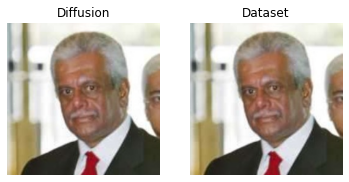

In [7]:
i = 0
df1 = df.loc[df[maxValueIndex[i]] == maxValues[i]]
display_image(df1.index[0], maxValueIndex[i])